### 1 加载数据

In [68]:
# 导入相关包
import warnings
warnings.filterwarnings('ignore')  # 屏蔽无关警告，让输出更干净
import numpy as np                # 数值计算库
import pandas as pd               # 表格数据处理库
import seaborn as sns             # 数据可视化库
import matplotlib.pyplot as plt

# 设置sns样式，让后续图表更美观
sns.set(style='white', context='notebook', palette='muted')
import matplotlib.pyplot as plt   # 绘图库，配合seaborn使用

# 导入数据
train =pd.read_csv('C:/Users/H/Downloads/train.csv')  # 读取训练集数据
test = pd.read_csv('C:/Users/H/Downloads/test.csv')   # 读取测试集数据
display(train.head())               # 显示训练集前5行数据

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2 数据探索

#### 2.1 数据查看

In [69]:
# 分别查看实验数据集和预测数据集数据
print('训练数据大小：', train.shape)
print('预测数据大小：', test.shape)

训练数据大小： (891, 12)
预测数据大小： (418, 11)


In [70]:
display(train.head(),test.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


#### 2.2 数据合并

In [71]:
# 将数据合并
full = pd.concat([train, test], ignore_index=True)
display(full.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


#### 2.3 查看数据信息

In [72]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


#### 2.4 特征与标签之间的关系

##### 2.4.1 港口和生还率的关系

<Axes: xlabel='Embarked', ylabel='Survived'>

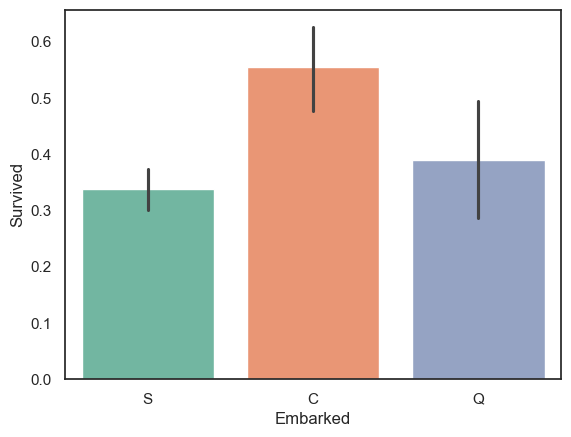

In [73]:
#港口和生死之间的关系
sns.barplot(data=train, x='Embarked', y='Survived',palette='Set2')

In [74]:
# 算出每个港口的人数和存活率
embarked_stats = train.groupby('Embarked')['Survived'].agg(
    人数='count',
    存活人数='sum',
    存活率='mean'
).reset_index()

display(embarked_stats)

,Embarked,人数,存活人数,存活率
0,C,168,93,0.553571
1,Q,77,30,0.389610
2,S,644,217,0.336957


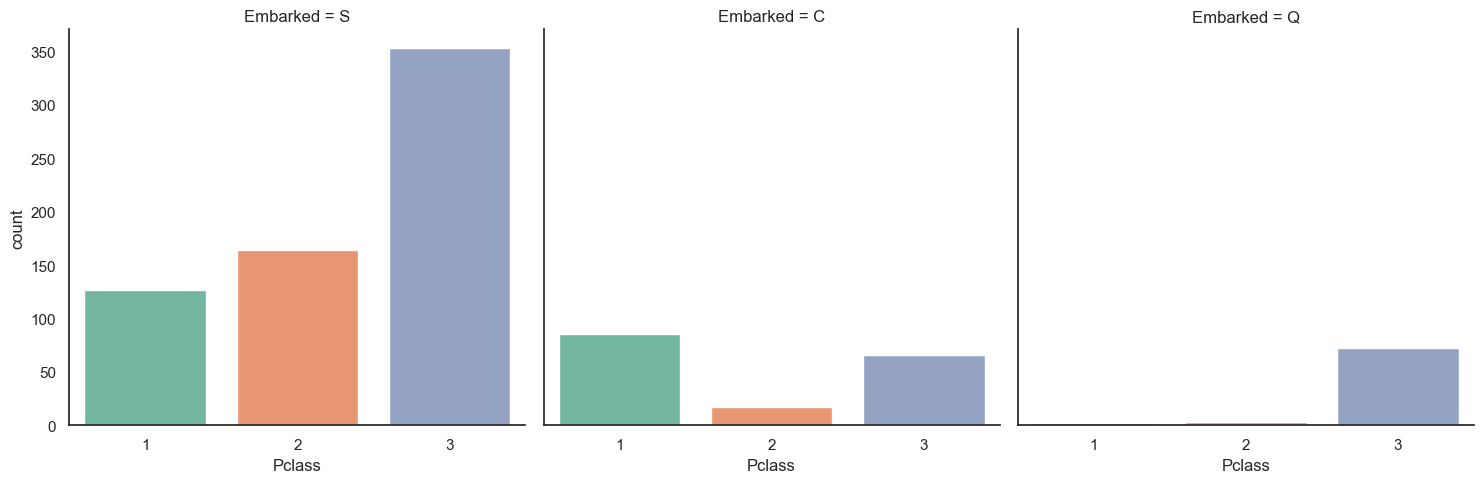

In [75]:
sns.catplot(
    x='Pclass', 
    col='Embarked', 
    data=train, 
    kind='count', 
    height=5,
    palette='Set2'
)

##### 2.4.2 票价和生还率之间的关系

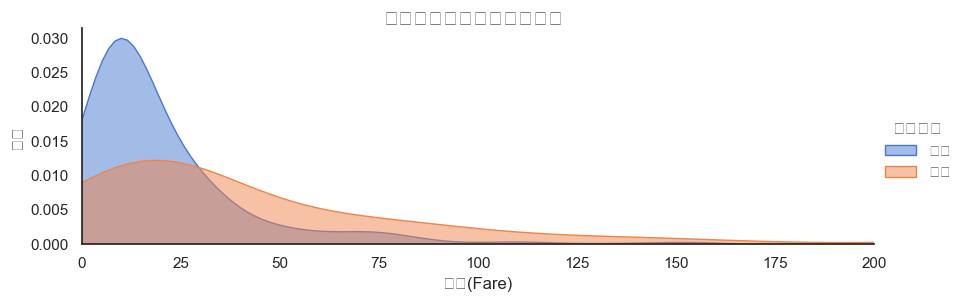

In [76]:
# 1. 创建 FacetGrid
ageFacet = sns.FacetGrid(train, hue='Survived', aspect=3, height=3)

# 2. 绘制 KDE 密度图
ageFacet.map(sns.kdeplot, 'Fare', shade=True, alpha=0.5)

# 3. 设置坐标轴和标题
ageFacet.set(xlim=(0, 200), xlabel='票价(Fare)', ylabel='密度')
ageFacet.fig.suptitle('不同生存状态下的票价分布', y=1)  

# 4. 添加图例并显示
ageFacet.add_legend(title='生存状态', labels=['死亡', '存活'])
plt.show()

##### 2.4.3 年龄和生还率之间的关系

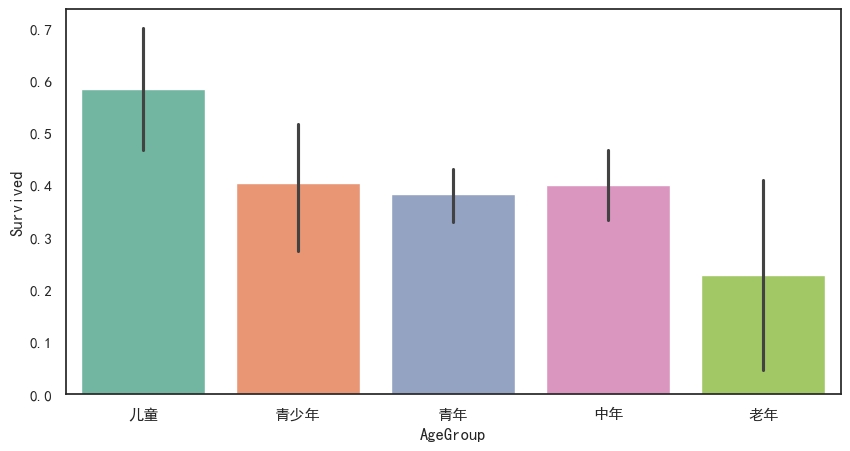

In [77]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
train['AgeGroup'] = pd.cut(
    train['Age'], 
    bins=[0,14,18,35,60,80], 
    labels=['儿童','青少年','青年','中年','老年']
)
plt.figure(figsize=(10, 5)) 
sns.barplot(data=train, x='AgeGroup', y='Survived',palette='Set2')
plt.show() 

##### 2.4.4 性别和生还率之间的关系

<Axes: xlabel='Sex', ylabel='Survived'>

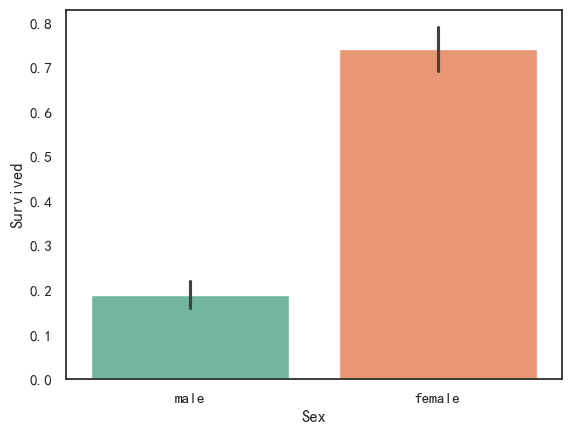

In [78]:
sns.barplot(data=train, x='Sex', y='Survived',palette='Set2')

##### 2.4.5 兄弟姐妹配偶数和生还率之间的关系

<Axes: xlabel='SibSp', ylabel='Survived'>

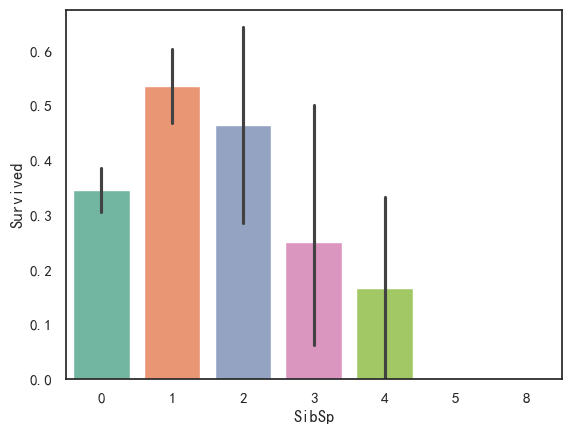

In [79]:
sns.barplot(data=train, x='SibSp', y='Survived',palette='Set2')

##### 2.4.6 父母孩子数和生还率之间的关系

<Axes: xlabel='Parch', ylabel='Survived'>

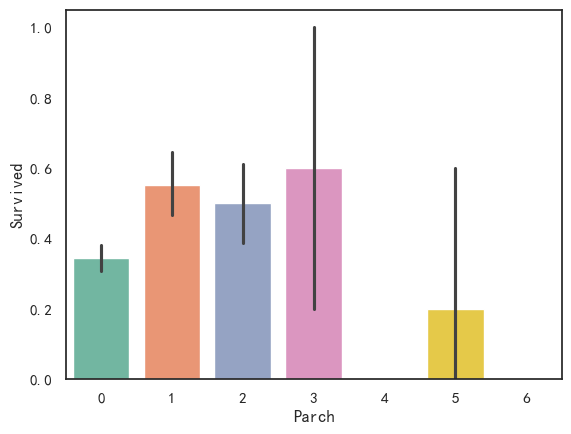

In [80]:
sns.barplot(data=train, x='Parch', y='Survived',palette='Set2')

##### 2.4.7 票级和生还率之间的关系

<Axes: xlabel='Pclass', ylabel='Survived'>

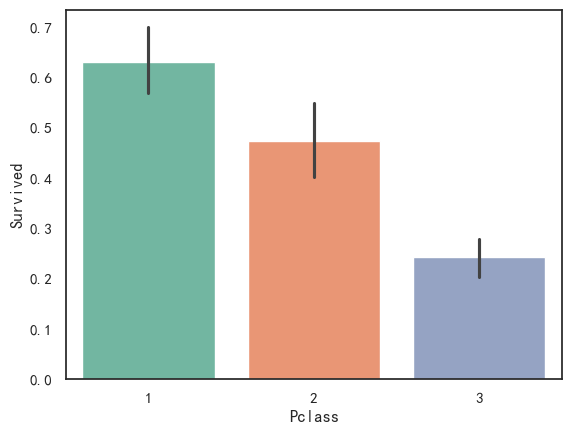

In [81]:
sns.barplot(data=train, x='Pclass', y='Survived',palette='Set2')

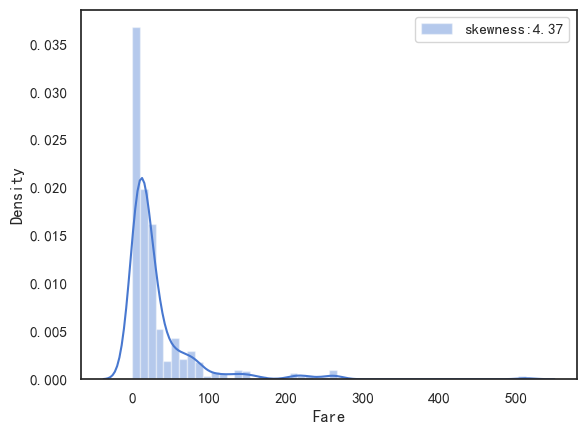

In [82]:
# 查看fare分布
farePlot = sns.distplot(
    full['Fare'][full['Fare'].notnull()], 
    label='skewness:%.2f' % (full['Fare'].skew())
)
farePlot.legend(loc='best')

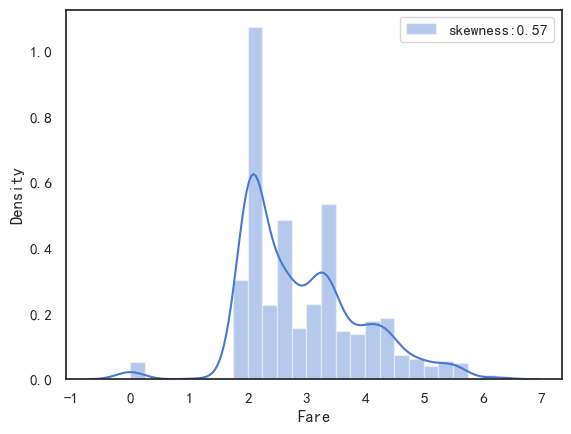

In [83]:
full['Fare'] = full['Fare'].map(lambda x: np.log(x) if x > 0 else x)
# 处理之后票价Fare分布
farePlot = sns.distplot(full['Fare'][full['Fare'].notnull()],
                        label='skewness:%.2f' % (full['Fare'].skew()))
farePlot.legend(loc='best')
plt.savefig('./10-Fare票价分布.png', dpi=200)

#### 2.5 数据预处理

##### 数据清洗

In [84]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [85]:
# 对Cabin缺失值进行处理，利用U（Unknown）填充缺失值
full['Cabin'] = full['Cabin'].fillna('U')
full['Cabin'].head()

0       U
1     C85
2       U
3    C123
4       U
Name: Cabin, dtype: object

In [86]:
# 对Embarked缺失值进行处理，查看缺失值情况
display(full[full['Embarked'].isnull()])
display(full['Embarked'].value_counts())

# 查看Embarked数据分布情况，可知在英国南安普顿登船可能性最大，因此以此填充缺失值。
full['Embarked']=full['Embarked'].fillna('S')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,4.382027,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,4.382027,B28,NaN


Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [87]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [88]:
# 查看缺失数据情况，该乘客乘坐3等舱，登船港口为法国，舱位未知
display(full[full['Fare'].isnull()])

# 利用3等舱，登船港口为英国，舱位未知旅客的平均票价来填充缺失值。
price = full[(full['Pclass']==3)&(full['Embarked']=='S')&(full['Cabin']=='U')]['Fare'].mean()
full['Fare'] = full['Fare'].fillna(price)
full.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,U,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


#### 2.6 特征工程

##### 2.6.1 头衔

In [89]:
# 构造新特征Title
full['Title'] = full['Name'].map(lambda x: x.split(',')[1].split('.')[0].strip())

# 查看title数据分布
full['Title'].value_counts()

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

In [90]:
TitleDict={}
# 普通男性头衔
TitleDict['Mr']='Mr'

# 未婚女性头衔
TitleDict['Mlle']='Miss'
TitleDict['Miss']='Miss'

# 未成年男性头衔
TitleDict['Master']='Master'
TitleDict['Jonkheer']='Master'

# 已婚女性头衔
TitleDict['Mme']='Mrs'
TitleDict['Ms']='Mrs'
TitleDict['Mrs']='Mrs'

# 贵族头衔
TitleDict['Don']='Royalty'
TitleDict['Sir']='Royalty'
TitleDict['the Countess']='Royalty'
TitleDict['Dona']='Royalty'
TitleDict['Lady']='Royalty'

# 军官/专业人士头衔
TitleDict['Capt']='Officer'
TitleDict['Col']='Officer'
TitleDict['Major']='Officer'
TitleDict['Dr']='Officer'
TitleDict['Rev']='Officer'

full['Title'] = full['Title'].map(TitleDict)
full['Title'].value_counts()

Title
Mr         757
Miss       262
Mrs        200
Master      62
Officer     23
Royalty      5
Name: count, dtype: int64

<Axes: xlabel='Title', ylabel='Survived'>

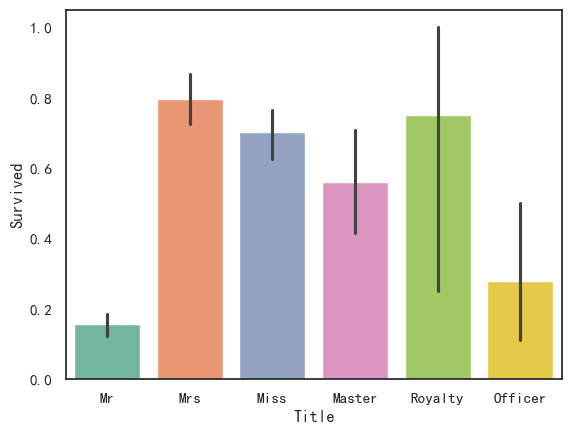

In [91]:
sns.barplot(data=full, x='Title', y='Survived', palette='Set2')

##### 2.6.2 家庭成员数

<Axes: xlabel='Family_num', ylabel='Survived'>

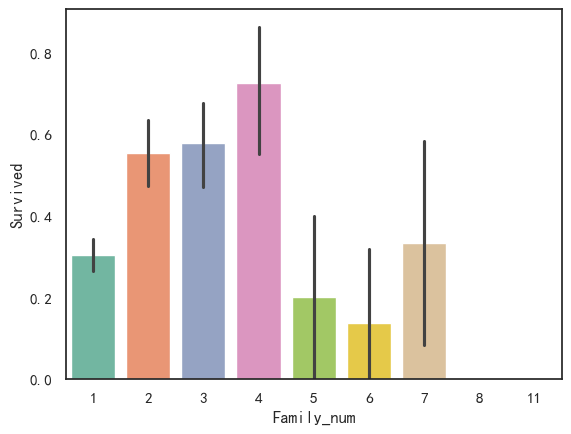

In [92]:
full['Family_num'] = full['Parch']+full['SibSp'] + 1
sns.barplot(data=full, x='Family_num', y='Survived', palette='Set2')

<Axes: xlabel='familySize', ylabel='Survived'>

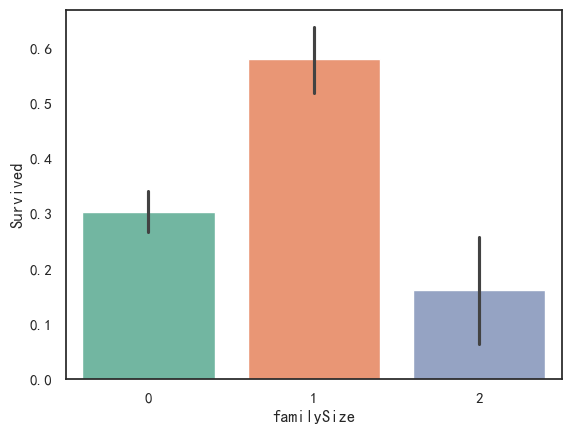

In [93]:
# 1. 定义分类函数
def familysize(Family_num):
    if Family_num == 1:
        return 0  # 小家庭：独自旅行
    elif 1 < Family_num <= 4:
        return 1  # 中家庭：2-4人同行
    else:
        return 2  # 大家庭：5人及以上同行

# 2. 生成新特征
full['familySize'] = full['Family_num'].map(familysize)
full['familySize'].value_counts()

# 3. 画柱状图看关系
sns.barplot(data=full, x='familySize', y='Survived',palette='Set2')

##### 2.6.3 船舱类型

In [94]:
full['Cabin'].unique()

array(['U', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

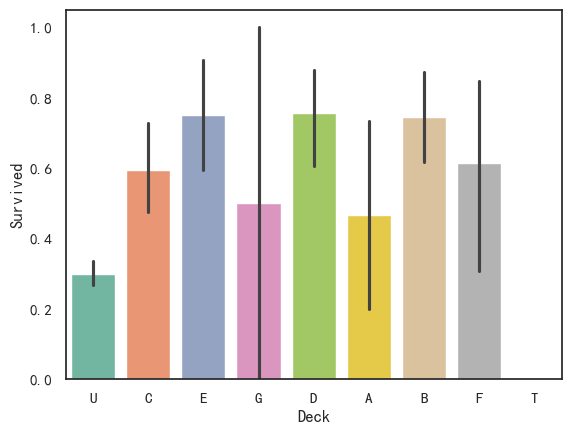

In [95]:
# 提取Cabin字段首字母
full['Deck'] = full['Cabin'].map(lambda x: x[0])

# 查看不同Deck类型乘客的生存率
sns.barplot(data=full, x='Deck', y='Survived',palette='Set2')
plt.savefig('./14-Deck与Survived关系.png', dpi=200)

##### 2.6.4 共号票乘客数量

In [96]:
# 提取各票号的乘客数量
TickCountDict = full['Ticket'].value_counts()
TickCountDict.head(20)

Ticket
CA. 2343        11
1601             8
CA 2144          8
347082           7
S.O.C. 14879     7
3101295          7
PC 17608         7
347077           7
382652           6
113781           6
19950            6
347088           6
W./C. 6608       5
349909           5
220845           5
4133             5
16966            5
PC 17757         5
113503           5
C.A. 34651       4
Name: count, dtype: int64

<Axes: xlabel='TickCom', ylabel='Survived'>

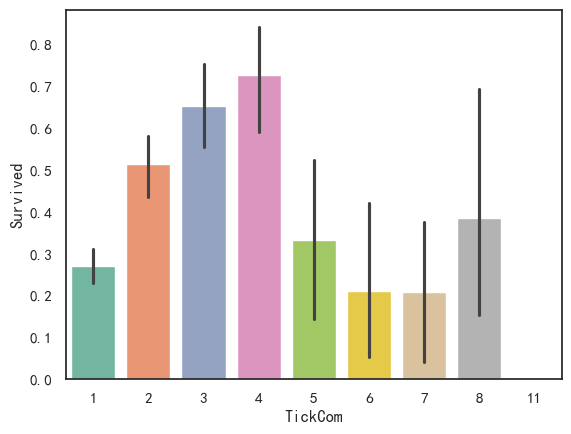

In [97]:
# 把每个乘客的票号对应的乘客数，映射到新列
full['TickCom'] = full['Ticket'].map(TickCountDict)
TickCountDict.head()
sns.barplot(data=full, x='TickCom', y='Survived',palette='Set2')

In [98]:
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_num,familySize,Deck,TickCom
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,U,S,Mr,2,1,U,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,Mrs,2,1,C,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,U,S,Miss,1,0,U,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,Mrs,2,1,C,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,U,S,Mr,1,0,U,1


<Axes: xlabel='TickGroup', ylabel='Survived'>

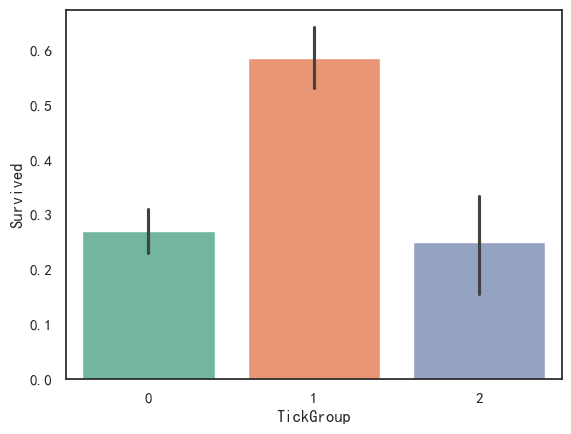

In [99]:
# 还可以像家庭规模一样，把人数分组（比如单人票、小团体、大团体）
def tickgroup(num):
    if num == 1:
        return 0  # 单人票
    elif 2 <= num <= 4:
        return 1  # 小团体
    else:
        return 2  # 大团体

full['TickGroup'] = full['TickCom'].map(tickgroup)
sns.barplot(data=full, x='TickGroup', y='Survived',palette='Set2')

#### 2.7 填充年龄

In [100]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
 12  Title        1309 non-null   object 
 13  Family_num   1309 non-null   int64  
 14  familySize   1309 non-null   int64  
 15  Deck         1309 non-null   object 
 16  TickCom      1309 non-null   int64  
 17  TickGroup    1309 non-null   int64  
dtypes: float64(3), int64(8), object(7)
memory usage:

In [101]:
full[full['Age'].notnull()].corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Family_num,familySize,TickCom,TickGroup
PassengerId,1.000000,0.029340,-0.064097,0.028814,-0.050700,-0.021096,0.038722,-0.044024,-0.048093,-0.013838,-0.015947
Survived,0.029340,1.000000,-0.359653,-0.077221,-0.017358,0.093317,0.342920,0.042787,0.106359,0.093239,0.160772
Pclass,-0.064097,-0.359653,1.000000,-0.408106,0.047221,0.017224,-0.741394,0.039602,-0.074864,-0.114293,-0.222827
Age,0.028814,-0.077221,-0.408106,1.000000,-0.243699,-0.150917,0.194038,-0.240229,-0.174901,-0.185284,-0.136441
SibSp,-0.050700,-0.017358,0.047221,-0.243699,1.000000,0.374456,0.294004,0.844260,0.779310,0.621362,0.583489
Parch,-0.021096,0.093317,0.017224,-0.150917,0.374456,1.000000,0.318137,0.813080,0.705738,0.641500,0.577684
Fare,0.038722,0.342920,-0.741394,0.194038,0.294004,0.318137,1.000000,0.368463,0.451368,0.603769,0.677698
Family_num,-0.044024,0.042787,0.039602,-0.240229,0.844260,0.813080,0.368463,1.000000,0.897180,0.760887,0.700225
familySize,-0.048093,0.106359,-0.074864,-0.174901,0.779310,0.705738,0.451368,0.897180,1.000000,0.661291,0.737373
TickCom,-0.013838,0.093239,-0.114293,-0.185284,0.621362,0.641500,0.603769,0.760887,0.661291,1.000000,0.898092


In [102]:
# 筛选数据集
agePre=full[['Age', 'Parch', 'Pclass', 'SibSp', 'Family_num', 'TickCom', 'Title', 'TickGroup']]
# 进行one-hot编码
agePre=pd.get_dummies(agePre)
ageCorrDf=agePre.corr()
ageCorrDf['Age'].sort_values()

Pclass          -0.408106
Title_Master    -0.385380
Title_Miss      -0.282977
SibSp           -0.243699
Family_num      -0.240229
TickCom         -0.185284
Parch           -0.150917
TickGroup       -0.136441
Title_Royalty    0.057337
Title_Officer    0.166771
Title_Mr         0.183965
Title_Mrs        0.215091
Age              1.000000
Name: Age, dtype: float64

In [103]:
agePre.head()

,Age,Parch,Pclass,SibSp,Family_num,TickCom,TickGroup,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
0,22.0,0,3,1,2,1,0,False,False,True,False,False,False
1,38.0,0,1,1,2,2,1,False,False,False,True,False,False
2,26.0,0,3,0,1,1,0,False,True,False,False,False,False
3,35.0,0,1,1,2,2,1,False,False,False,True,False,False
4,35.0,0,3,0,1,1,0,False,False,True,False,False,False


In [104]:
# 拆分实验集和预测集
ageKnown = agePre[agePre['Age'].notnull()]  # 有年龄的样本，用来训练模型
ageUnKnown = agePre[agePre['Age'].isnull()] # 缺失年龄的样本，用来预测填充
# 生成实验数据的特征和标签
ageKnown_X = ageKnown.drop(['Age'], axis=1)  # 去掉Age列，得到特征
ageKnown_y = ageKnown['Age']                # Age列本身就是标签（要预测的目标）
# 生成预测数据的特征
ageUnKnown_X = ageUnKnown.drop(['Age'], axis=1)
# 利用随机森林构建模型
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=None, n_estimators=500, n_jobs=-1)
rfr.fit(ageKnown_X, ageKnown_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
#模型得分
score = rfr.score(ageKnown_X, ageKnown_y)
print('模型预测年龄得分是：', score)
#预测年龄
ageUnKnown_predict = rfr.predict(ageUnKnown_X)
#填充预测数据
full.loc[full['Age'].isnull(), ['Age']] = ageUnKnown_predict
full.info()

模型预测年龄得分是： 0.5865892001103157
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        1309 non-null   object 
 11  Embarked     1309 non-null   object 
 12  Title        1309 non-null   object 
 13  Family_num   1309 non-null   int64  
 14  familySize   1309 non-null   int64  
 15  Deck         1309 non-null   object 
 16  TickCom      1309 non-null   int64  
 17  TickGroup    1309 non-null   int64  
dtypes: float64(3), int

In [106]:
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_num,familySize,Deck,TickCom,TickGroup
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,U,S,Mr,2,1,U,1,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,Mrs,2,1,C,2,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,U,S,Miss,1,0,U,1,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,Mrs,2,1,C,2,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,U,S,Mr,1,0,U,1,0


#### 2.8 同组识别

In [107]:
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_num,familySize,Deck,TickCom,TickGroup
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,1.981001,U,S,Mr,2,1,U,1,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.266662,C85,C,Mrs,2,1,C,2,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.070022,U,S,Miss,1,0,U,1,0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.972177,C123,S,Mrs,2,1,C,2,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.085672,U,S,Mr,1,0,U,1,0


#### 2.9 条件筛选

In [108]:
# 1. 人工筛选特征
fullSel = full.drop(
    ['Cabin', 'Name', 'Ticket', 'PassengerId', 'Surname', 'SurnameNum', 'Deck' ], 
    errors='ignore',
    axis=1
)

# 2. 相关性分析
corrDf = fullSel.corr(numeric_only=True)
print(corrDf['Survived'].sort_values(ascending=True))

Pclass       -0.338481
Age          -0.059779
SibSp        -0.035322
Family_num    0.016639
TickCom       0.064962
Parch         0.081629
familySize    0.108631
TickGroup     0.151702
Fare          0.331805
Survived      1.000000
Name: Survived, dtype: float64


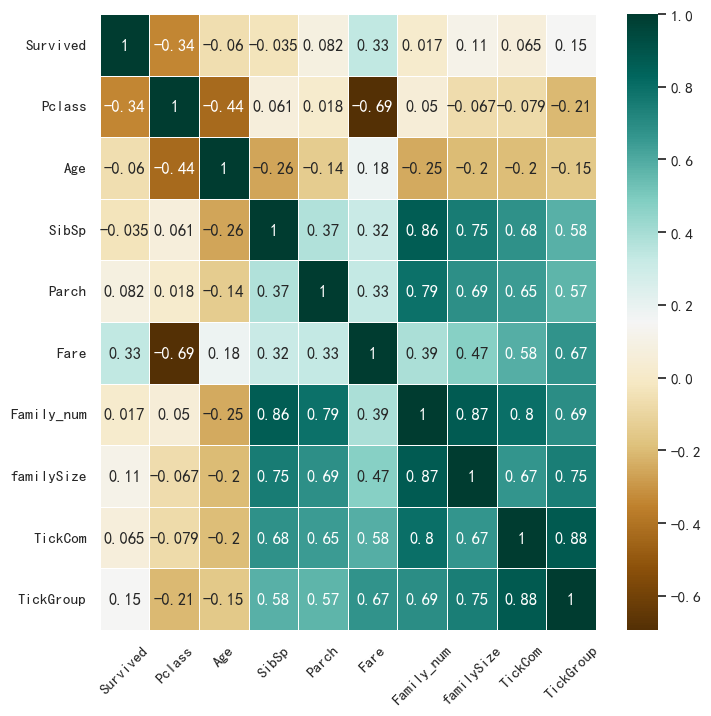

In [109]:
# 3. 热力图
plt.figure(figsize=(8,8))
sns.heatmap(
    fullSel.corr(numeric_only=True),  
    cmap='BrBG',
    annot=True,
    linewidths=.5
)
plt.xticks(rotation=45)
plt.show()

In [110]:
# 4. 删除低相关特征
fullSel = fullSel.drop(['Age','Parch','SibSp','Family_num','TickCom'], axis=1)

# 5. 再对剩下的分类特征做one-hot编码
fullSel = pd.get_dummies(fullSel)
fullSel.head()

,Survived,Pclass,Fare,familySize,TickGroup,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
0,0.0,3,1.981001,1,0,False,True,False,False,True,False,False,True,False,False,False
1,1.0,1,4.266662,1,1,True,False,True,False,False,False,False,False,True,False,False
2,1.0,3,2.070022,0,0,True,False,False,False,True,False,True,False,False,False,False
3,1.0,1,3.972177,1,1,True,False,False,False,True,False,False,False,True,False,False
4,0.0,3,2.085672,0,0,False,True,False,False,True,False,False,True,False,False,False


### 3 算法建模

#### 3.1 模型选择

In [111]:
# 拆分实验数据与预测数据
experData=fullSel[fullSel['Survived'].notnull()] #已有数据
preData=fullSel[fullSel['Survived'].isnull()] #预测数据

experData_X=experData.drop('Survived',axis=1)
experData_y=experData['Survived']

preData_X=preData.drop('Survived',axis=1)

# 导入机器学习算法库
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score,StratifiedKFold

# 设置kfold，交叉采样法拆分数据集
kfold=StratifiedKFold(n_splits=10)

# 汇总不同模型算法
classifiers=[]
classifiers.append(SVC())
classifiers.append(DecisionTreeClassifier())
classifiers.append(RandomForestClassifier())
classifiers.append(ExtraTreesClassifier())
classifiers.append(GradientBoostingClassifier())
classifiers.append(KNeighborsClassifier())
classifiers.append(LogisticRegression())
classifiers.append(LinearDiscriminantAnalysis())
classifiers.append(XGBClassifier())

In [112]:
# 不同机器学习交叉验证结果汇总
cv_results=[]
for classifier in classifiers:
    cv_results.append(cross_val_score(classifier, experData_X, experData_y, 
                                        scoring='accuracy', cv=kfold, n_jobs=-1))

# 求出模型得分的均值和标准差
cv_means=[]
cv_std=[]
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

# 汇总数据
cvResDf=pd.DataFrame({'cv_mean':cv_means,
                      'cv_std':cv_std,
                      'algorithm':['SVC','DecisionTreeCla','RandomForestCla','ExtraTreesCla',
                                   'GradientBoostingCla','KNN','LR','LDA','Xgboost']})

cvResDf

,cv_mean,cv_std,algorithm
0,0.836130,0.035283,SVC
1,0.817079,0.027854,DecisionTreeCla
2,0.813758,0.032915,RandomForestCla
3,0.807004,0.027949,ExtraTreesCla
4,0.838390,0.044125,GradientBoostingCla
5,0.830574,0.041633,KNN
6,0.814819,0.029800,LR
7,0.824919,0.032231,LDA
8,0.829463,0.046803,Xgboost


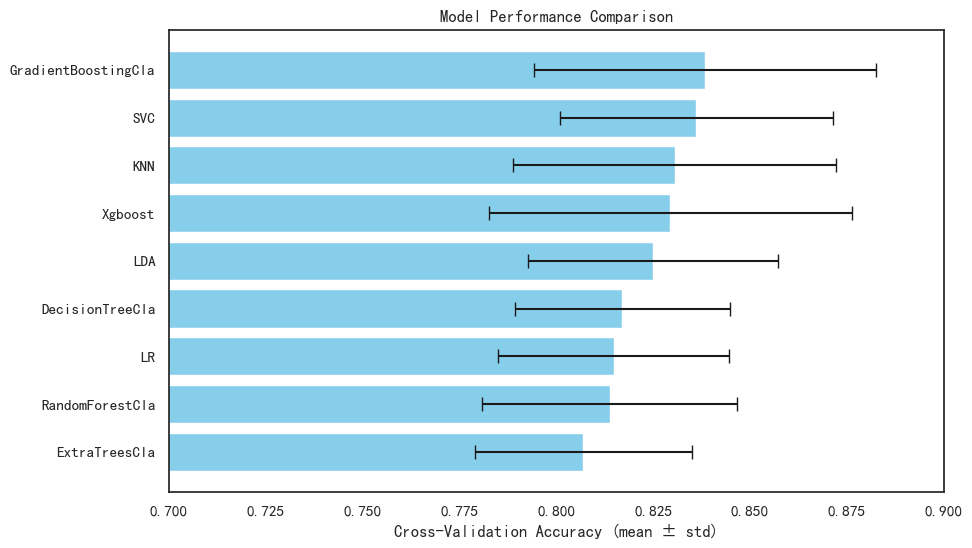

In [113]:
# 按准确率从高到低排序
cvResDf_sorted = cvResDf.sort_values(by='cv_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    cvResDf_sorted['algorithm'],
    cvResDf_sorted['cv_mean'],
    xerr=cvResDf_sorted['cv_std'],
    capsize=5,
    color='skyblue'
)

plt.gca().invert_yaxis()  # 让准确率最高的在最上面
plt.xlim(0.7, 0.9)
plt.xlabel('Cross-Validation Accuracy (mean ± std)')
plt.title('Model Performance Comparison')
plt.show()

#### 3.2 模型调优

In [114]:
# SVC调参
# 在模型调优部分修改SVC的GridSearch
param_grid_svc = {
    'C': [0.5, 1, 1.5, 2, 3],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear'],
    'probability': [True]  # 关键：启用概率预测
}

grid_svc = GridSearchCV(SVC(), param_grid_svc, cv=10, scoring='accuracy', n_jobs=-1)
grid_svc.fit(experData_X, experData_y)

print("SVC最佳参数:", grid_svc.best_params_)
print("SVC最佳交叉验证准确率:", grid_svc.best_score_)

SVC最佳参数: {'C': 0.5, 'gamma': 0.1, 'kernel': 'rbf', 'probability': True}
SVC最佳交叉验证准确率: 0.8361298377028714


In [115]:
# XGBoost调参

param_grid_xgb_v2 = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0, 0.1, 0.2, 0.5],
    'min_child_weight': [1, 2, 3, 5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.5, 1, 1.5]
}

from sklearn.model_selection import RandomizedSearchCV

random_xgb = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_distributions=param_grid_xgb_v2,
    n_iter=50,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_xgb.fit(experData_X, experData_y)

print("XGBoost最佳参数:", random_xgb.best_params_)
print("XGBoost最佳交叉验证准确率:", random_xgb.best_score_) 

# 保存最佳模型
modelgsXGB = random_xgb.best_estimator_  

XGBoost最佳参数: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}
XGBoost最佳交叉验证准确率: 0.8429338327091136


In [116]:
#LDA（线性判别分析）调参

# 1. 参数网格
param_grid_lda = {
    'solver': ['svd', 'lsqr', 'eigen'],  # 三种求解器
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]  # 收缩（仅lsqr/eigen可用）
}

# 2. 网格搜索
grid_lda = GridSearchCV(
    estimator=LinearDiscriminantAnalysis(),
    param_grid=param_grid_lda,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

# 3. 训练+搜索
grid_lda.fit(experData_X, experData_y)

# 4. 输出结果
print("LDA最佳参数:", grid_lda.best_params_)
print("LDA最佳交叉验证准确率:", grid_lda.best_score_)

LDA最佳参数: {'shrinkage': None, 'solver': 'lsqr'}
LDA最佳交叉验证准确率: 0.8260424469413234


In [117]:
#GradientBoosting（梯度提升）调参

# 1. 更精细的参数网格
param_grid_gbc = {
    'n_estimators': [200, 500, 800],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 0.7]
}

# 2. 网格搜索（10折交叉验证）
grid_gbc = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gbc,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. 训练
grid_gbc.fit(experData_X, experData_y)

# 4. 输出结果
print("最佳参数:", grid_gbc.best_params_)
print("最佳交叉验证准确率:", grid_gbc.best_score_)

# 保存最佳模型
modelgsGBC = grid_gbc.best_estimator_

Fitting 10 folds for each of 324 candidates, totalling 3240 fits
最佳参数: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 0.7, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.7}
最佳交叉验证准确率: 0.8384269662921348


#### 3.3 模型评估

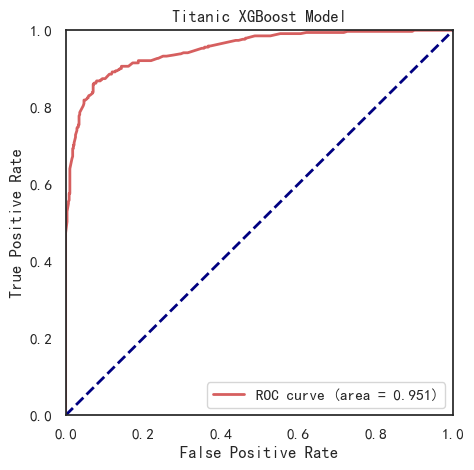

In [118]:
# 查看XGBoost模型ROC曲线
# 求出测试数据集的预测值（用 best_estimator_，变量名统一）
modelsXGB = random_xgb.best_estimator_  # ← 改成 random_xgb
modelsXGBtestpre_y = modelsXGB.predict_proba(experData_X)[:, 1]  # ← 同时检查变量名

# 画图
from sklearn.metrics import roc_curve, auc

# 计算ROC曲线和AUC值
fpr, tpr, threshold = roc_curve(experData_y, modelsXGBtestpre_y)
roc_auc = auc(fpr, tpr)

# 绘制ROC曲线
lw = 2
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='r', lw=lw, label='ROC curve (area = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic XGBoost Model')
plt.legend(loc='lower right')
plt.show()

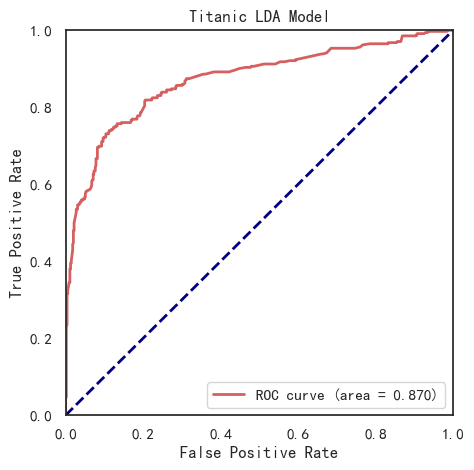

In [119]:
# 查看LDA模型ROC曲线
# 求出测试数据模型的预测值
modelgsLDAtestpre_y = grid_lda.predict_proba(experData_X)[:, 1]

# 画图
from sklearn.metrics import roc_curve, auc  # 导入计算roc和auc的工具

# 计算ROC曲线和AUC值
# 计算真正率(TPR)和假正率(FPR)
fpr, tpr, threshold = roc_curve(experData_y, modelgsLDAtestpre_y)
roc_auc = auc(fpr, tpr)  # 计算AUC的值

# 绘制ROC曲线
lw = 2
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='r',
         lw=lw, label='ROC curve (area = %0.3f)' % roc_auc)  # 假正率为横坐标，真正率为纵坐标做曲线

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic LDA Model')
plt.legend(loc="lower right")
plt.show()

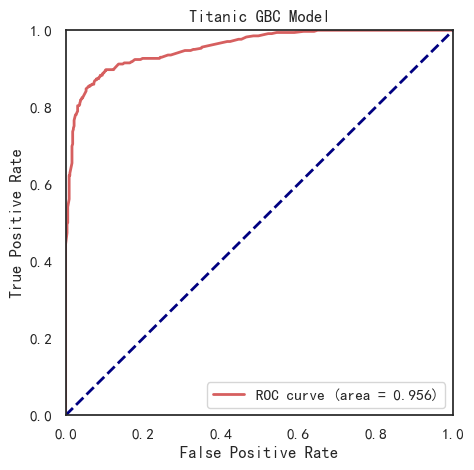

In [120]:
# 查看GBC模型ROC曲线
# 求出测试数据模型的预测值
modelgsGBCtestpre_y = grid_gbc.predict_proba(experData_X)[:, 1]

# 画图
from sklearn.metrics import roc_curve, auc  # 导入计算roc和auc的工具

# 计算ROC曲线和AUC值
# 计算真正率(TPR)和假正率(FPR)
fpr, tpr, threshold = roc_curve(experData_y, modelgsGBCtestpre_y)
roc_auc = auc(fpr, tpr)  # 计算AUC的值

# 绘制ROC曲线
lw = 2
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='r',
         lw=lw, label='ROC curve (area = %0.3f)' % roc_auc)  # 假正率为横坐标，真正率为纵坐标做曲线

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic GBC Model')
plt.legend(loc="lower right")
plt.show()

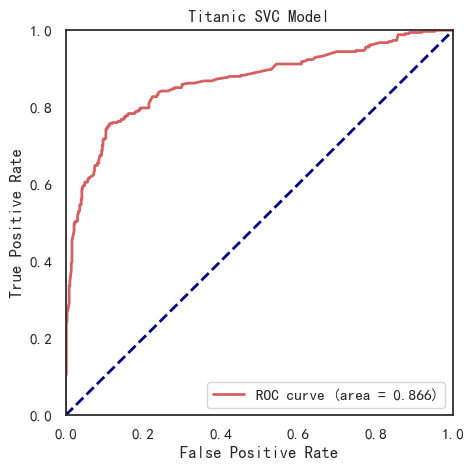

In [121]:
# 查看SVC模型ROC曲线
modelgsSVC = grid_svc.best_estimator_
y_score = modelgsSVC.decision_function(experData_X)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(experData_y, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
lw = 2
plt.plot(fpr, tpr, color='r', lw=lw,
         label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Titanic SVC Model')
plt.legend(loc="lower right")
plt.show()

#### 3.4 混淆矩阵

In [122]:
# 混淆矩阵
from sklearn.metrics import confusion_matrix

# 先把概率转成 0/1 标签（阈值 0.5）
GBC_pred = (modelgsGBCtestpre_y > 0.5).astype(int)
XGB_pred = (modelsXGBtestpre_y > 0.5).astype(int)
SVC_pred = (y_score > 0).astype(int)  # SVC 的 decision_function 以 0 为阈值
LDA_pred = (modelgsLDAtestpre_y > 0.5).astype(int)

# 打印混淆矩阵
print('GradientBoostingClassifier模型混淆矩阵为\n',
      confusion_matrix(experData_y, GBC_pred))

print('XGBoost模型混淆矩阵为\n',
      confusion_matrix(experData_y, XGB_pred))

print('SVC模型混淆矩阵为\n',
      confusion_matrix(experData_y, SVC_pred))

print('LDA模型混淆矩阵为\n',
      confusion_matrix(experData_y, LDA_pred))

GradientBoostingClassifier模型混淆矩阵为
 [[517  32]
 [ 50 292]]
XGBoost模型混淆矩阵为
 [[517  32]
 [ 59 283]]
SVC模型混淆矩阵为
 [[492  57]
 [ 88 254]]
LDA模型混淆矩阵为
 [[488  61]
 [ 90 252]]


In [123]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 定义函数简化重复代码
def evaluate_model(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n{model_name}:")
    print(f"  混淆矩阵:\n{cm}")
    print(f"  准确率={accuracy:.4f}, 精确率={precision:.4f}, 召回率={recall:.4f}, 特异度={specificity:.4f}, F1={f1:.4f}")
    return accuracy, precision, recall, specificity, f1

# 评估各模型
evaluate_model(experData_y, (modelgsGBCtestpre_y > 0.5).astype(int), "GradientBoosting")
evaluate_model(experData_y, (modelsXGBtestpre_y > 0.5).astype(int), "XGBoost")
evaluate_model(experData_y, (y_score > 0).astype(int), "SVC")
evaluate_model(experData_y, (modelgsLDAtestpre_y > 0.5).astype(int), "LDA")


GradientBoosting:
  混淆矩阵:
[[517  32]
 [ 50 292]]
  准确率=0.9080, 精确率=0.9012, 召回率=0.8538, 特异度=0.9417, F1=0.8769

XGBoost:
  混淆矩阵:
[[517  32]
 [ 59 283]]
  准确率=0.8979, 精确率=0.8984, 召回率=0.8275, 特异度=0.9417, F1=0.8615

SVC:
  混淆矩阵:
[[492  57]
 [ 88 254]]
  准确率=0.8373, 精确率=0.8167, 召回率=0.7427, 特异度=0.8962, F1=0.7779

LDA:
  混淆矩阵:
[[488  61]
 [ 90 252]]
  准确率=0.8305, 精确率=0.8051, 召回率=0.7368, 特异度=0.8889, F1=0.7695


(0.8305274971941639,
 0.805111821086262,
 0.7368421052631579,
 np.float64(0.8888888888888888),
 0.7694656488549618)

In [124]:
from sklearn.ensemble import VotingClassifier

# 注意：这里要用你实际定义的变量名
# grid_gbc, random_xgb, grid_svc, grid_lda

# 如果之前用的是 random_xgb，需要改成 random_xgb
# 只用 GBC + XGB
ensemble_soft = VotingClassifier(
    estimators=[('gbc', grid_gbc.best_estimator_), ('xgb', random_xgb.best_estimator_)],
    voting='soft',
    weights=[2, 1]
)

ensemble_soft.fit(experData_X, experData_y)

# 预测
ensemble_pre = ensemble_soft.predict(preData_X).astype(int)
ensemble_proba = ensemble_soft.predict_proba(preData_X)[:, 1]

# 保存结果
ensemble_result = pd.DataFrame({
    'PassengerId': full['PassengerId'][full['Survived'].isnull()],
    'Survived': ensemble_pre
})
ensemble_result.to_csv('./Titanic_ensemble_Soft.csv', index=False)
print(ensemble_result.head())

     PassengerId  Survived
891          892         0
892          893         1
893          894         0
894          895         0
895          896         1


In [125]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
